<a href="https://colab.research.google.com/github/santhoshjothi540/CREDIT_CARD_FRAUD_DETECTION/blob/main/CREDIT_CARD_FRAUD_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CREDIT CARD FRAUD DETECTION

In [1]:
# Import Required Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [2]:
# Beautiful Graph Theme
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.facecolor"] = "#F7F9FC"
plt.rcParams["figure.facecolor"] = "white"

plt.rcParams["axes.edgecolor"] = "#2D3436"

plt.rcParams["axes.titleweight"] = "bold"

plt.rcParams["axes.labelweight"] = "bold"

plt.rcParams["font.size"] = 12

In [3]:
#upload dataset
from google.colab import files

uploaded = files.upload()

Saving credit_card_fraud_10k.csv to credit_card_fraud_10k.csv


In [4]:
#Read the dataset
df = pd.read_csv("credit_card_fraud_10k.csv")

In [5]:
#Display First Five Records
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [6]:
#Display Last Five Records
df.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [7]:
# Shape of Dataset
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 10000
Columns : 10


In [8]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [9]:
#Column Names
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [10]:
# Missing Values
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [11]:
# Duplicate Records
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
df = df.drop_duplicates()

In [13]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,5000.500000,2886.895680,1.0,2500.750,5000.500,7500.25,10000.00
amount,10000.0,175.949849,175.392827,0.0,50.905,122.095,242.48,1471.04
transaction_hour,10000.0,11.593300,6.922708,0.0,6.000,12.000,18.00,23.00
foreign_transaction,10000.0,0.097800,0.297059,0.0,0.000,0.000,0.00,1.00
location_mismatch,10000.0,0.085700,0.279935,0.0,0.000,0.000,0.00,1.00
device_trust_score,10000.0,61.798900,21.487053,25.0,43.000,62.000,80.00,99.00
velocity_last_24h,10000.0,2.008900,1.432559,0.0,1.000,2.000,3.00,9.00
cardholder_age,10000.0,43.468700,14.979147,18.0,30.000,44.000,56.00,69.00
is_fraud,10000.0,0.015100,0.121957,0.0,0.000,0.000,0.00,1.00


In [14]:
# Data Types
df.dtypes

,0
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,object
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64
is_fraud,int64


In [15]:
#Unique Values
df.nunique()

,0
transaction_id,10000
amount,8788
transaction_hour,24
merchant_category,5
foreign_transaction,2
location_mismatch,2
device_trust_score,75
velocity_last_24h,10
cardholder_age,52
is_fraud,2


In [16]:
# Fraud Distribution
df["is_fraud"].value_counts()

,count
is_fraud,
0,9849
1,151


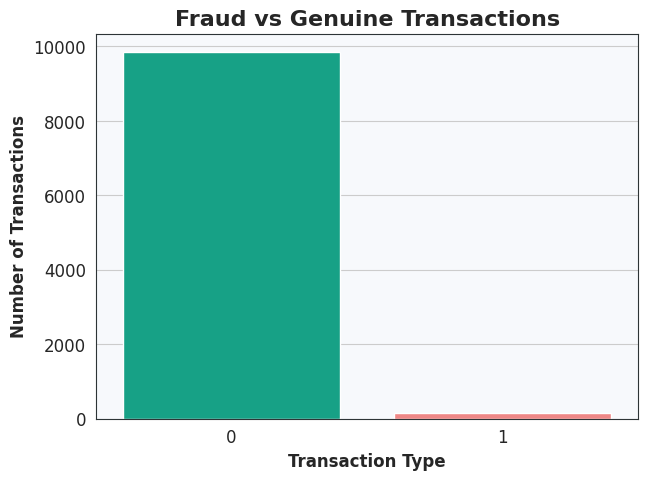

In [17]:
# Fraud Distribution Graph
plt.figure(figsize=(7,5))

colors=["#00B894","#FF7675"]

sns.countplot(
    x="is_fraud",
    data=df,
    palette=colors
)

plt.title("Fraud vs Genuine Transactions",fontsize=16)

plt.xlabel("Transaction Type")

plt.ylabel("Number of Transactions")

plt.show()

In [18]:
#Fraud Percentage
fraud_percentage = (
    df["is_fraud"]
    .value_counts(normalize=True)
    *100
)

print(fraud_percentage)

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


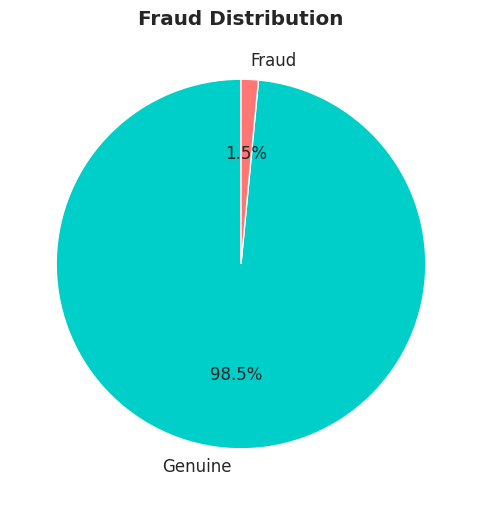

In [19]:
# Check Class Balance
plt.figure(figsize=(6,6))

plt.pie(
    df["is_fraud"].value_counts(),
    labels=["Genuine","Fraud"],
    autopct="%1.1f%%",
    colors=["#00CEC9","#FF7675"],
    startangle=90
)

plt.title("Fraud Distribution")

plt.show()

Exploratory Data Analysis (EDA)

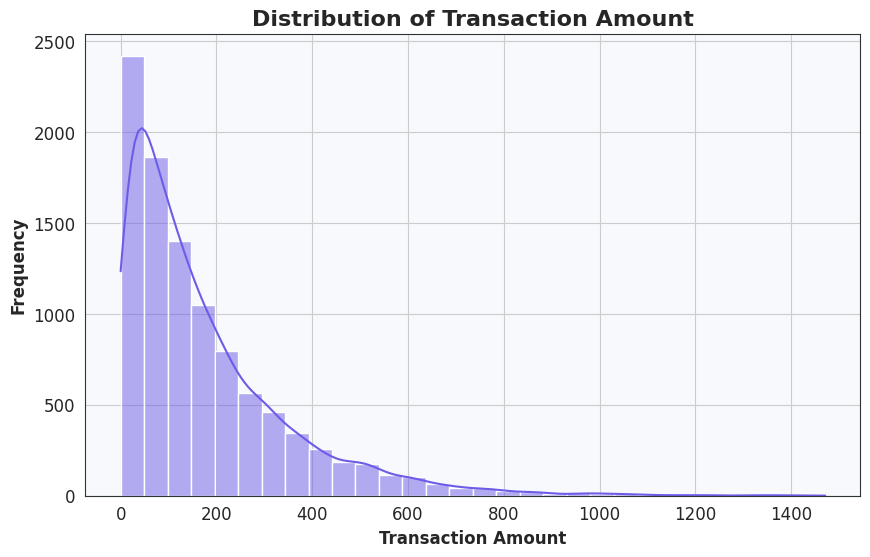

In [20]:
# Distribution of Transaction Amount
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="amount",
    bins=30,
    color="#6C5CE7",
    kde=True
)

plt.title("Distribution of Transaction Amount",fontsize=16)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

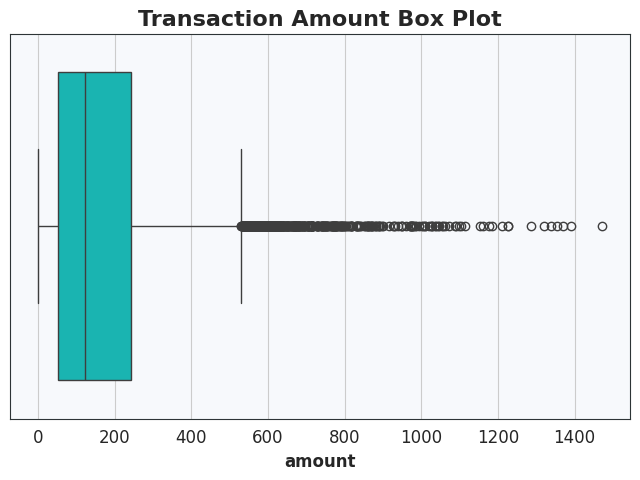

In [21]:
# Box Plot of Transaction Amount
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["amount"],
    color="#00CEC9"
)

plt.title("Transaction Amount Box Plot",fontsize=16)

plt.show()

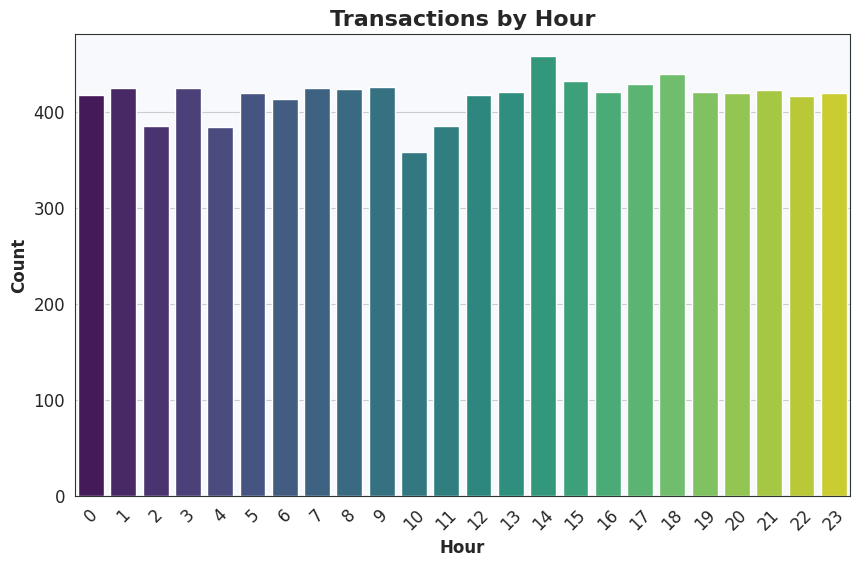

In [22]:
# Transaction Hour Distribution
plt.figure(figsize=(10,6))

sns.countplot(
    x="transaction_hour",
    data=df,
    palette="viridis"
)

plt.title("Transactions by Hour",fontsize=16)

plt.xlabel("Hour")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

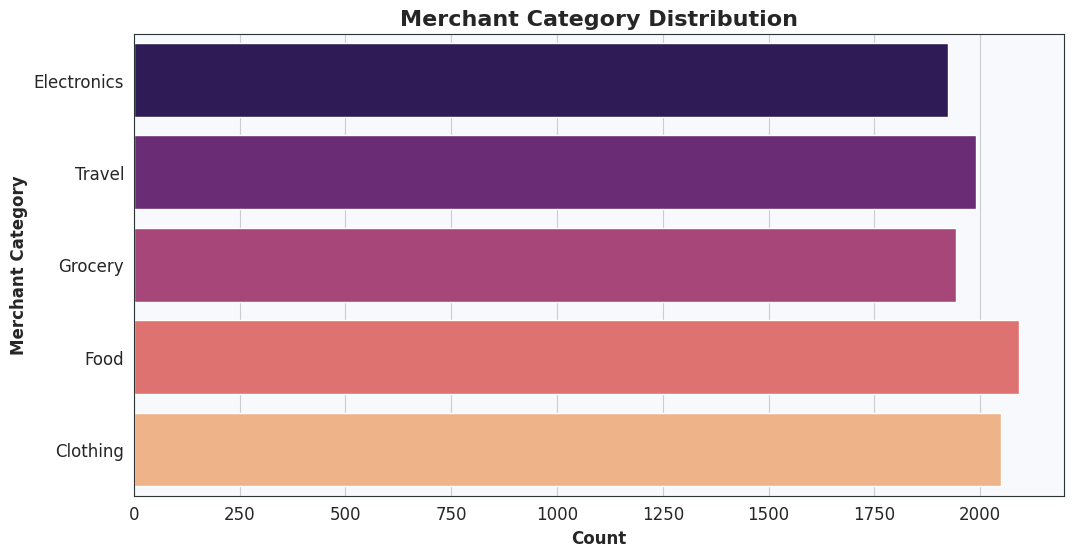

In [23]:
# Merchant Category Distribution
plt.figure(figsize=(12,6))

sns.countplot(
    y="merchant_category",
    data=df,
    palette="magma"
)

plt.title("Merchant Category Distribution",fontsize=16)

plt.xlabel("Count")

plt.ylabel("Merchant Category")

plt.show()

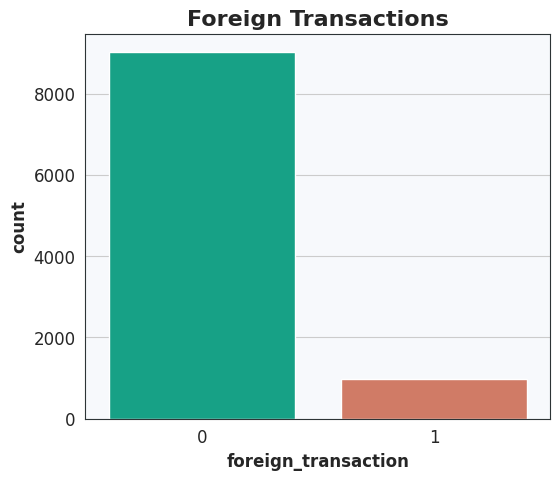

In [24]:
# Foreign Transactions
plt.figure(figsize=(6,5))

sns.countplot(
    x="foreign_transaction",
    data=df,
    palette=["#00B894","#E17055"]
)

plt.title("Foreign Transactions",fontsize=16)

plt.show()

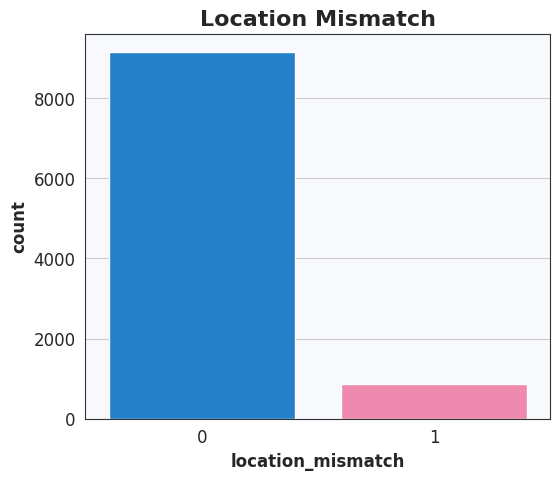

In [25]:
# Location Mismatch
plt.figure(figsize=(6,5))

sns.countplot(
    x="location_mismatch",
    data=df,
    palette=["#0984E3","#FD79A8"]
)

plt.title("Location Mismatch",fontsize=16)

plt.show()

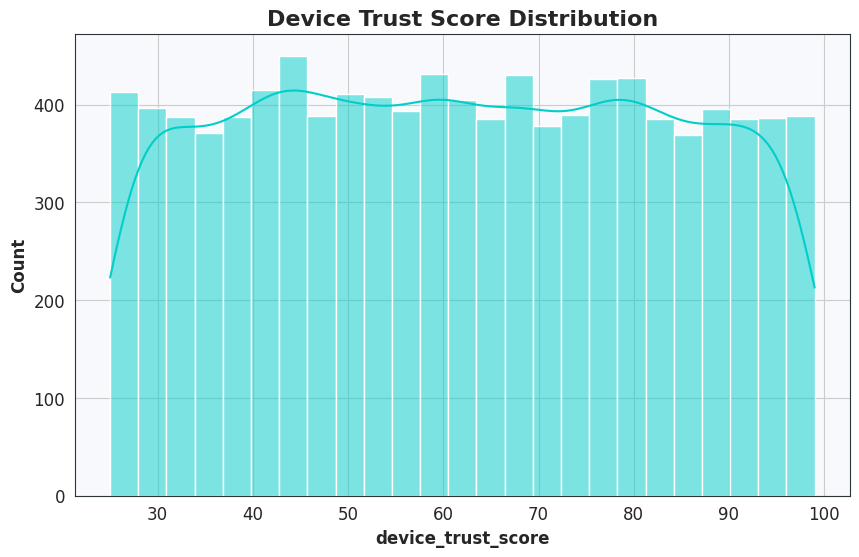

In [26]:
# Device Trust Score Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df["device_trust_score"],
    bins=25,
    kde=True,
    color="#00CEC9"
)

plt.title("Device Trust Score Distribution",fontsize=16)

plt.show()

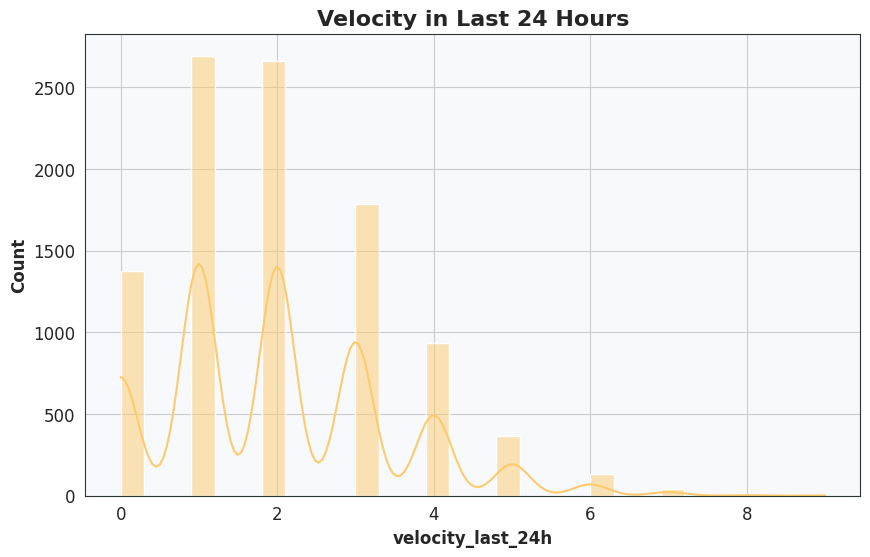

In [27]:
# Velocity in Last 24 Hours
plt.figure(figsize=(10,6))

sns.histplot(
    df["velocity_last_24h"],
    bins=30,
    kde=True,
    color="#FDCB6E"
)

plt.title("Velocity in Last 24 Hours",fontsize=16)

plt.show()

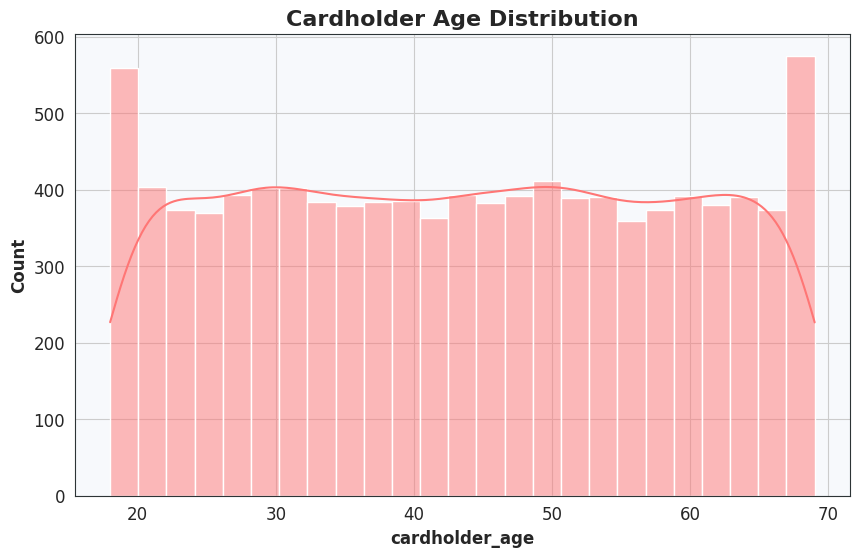

In [29]:
# Cardholder Age Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df["cardholder_age"],
    bins=25,
    kde=True,
    color="#FF7675"
)

plt.title("Cardholder Age Distribution",fontsize=16)

plt.show()

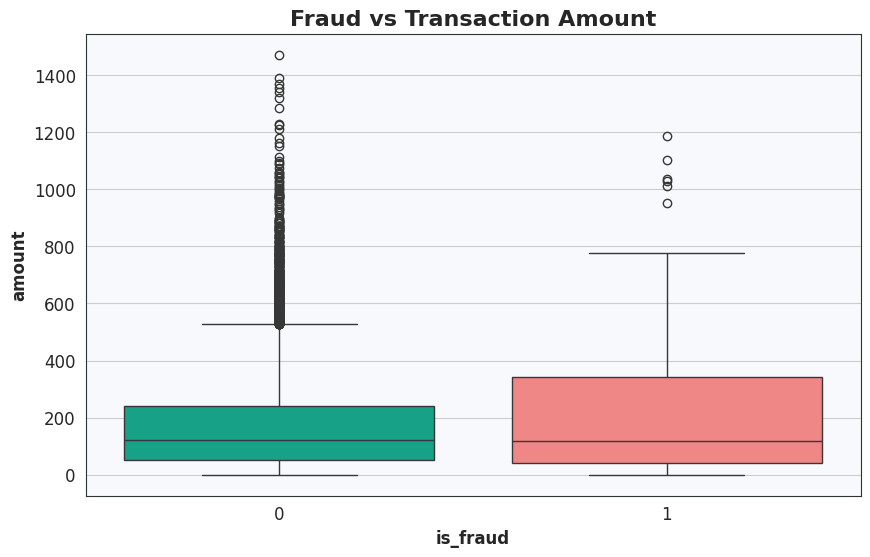

In [30]:
# Fraud vs Amount
plt.figure(figsize=(10,6))

sns.boxplot(
    x="is_fraud",
    y="amount",
    data=df,
    palette=["#00B894","#FF7675"]
)

plt.title("Fraud vs Transaction Amount",fontsize=16)

plt.show()

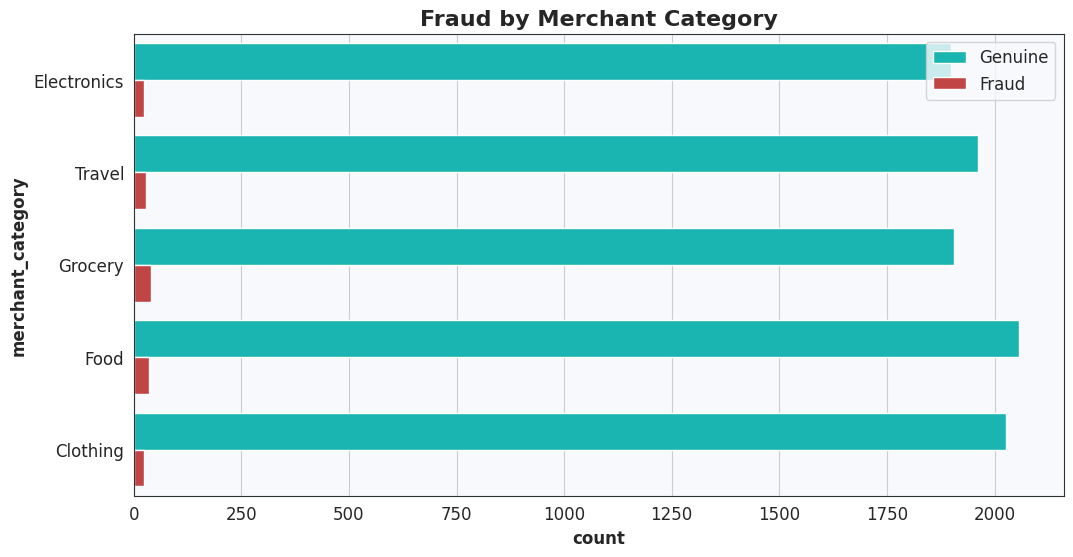

In [31]:
# Fraud by Merchant Category
plt.figure(figsize=(12,6))

sns.countplot(
    y="merchant_category",
    hue="is_fraud",
    data=df,
    palette=["#00CEC9","#D63031"]
)

plt.title("Fraud by Merchant Category",fontsize=16)

plt.legend(["Genuine","Fraud"])

plt.show()

Correlation Heatmap

In [32]:
corr_df = df.drop(columns=["transaction_id"], errors="ignore")

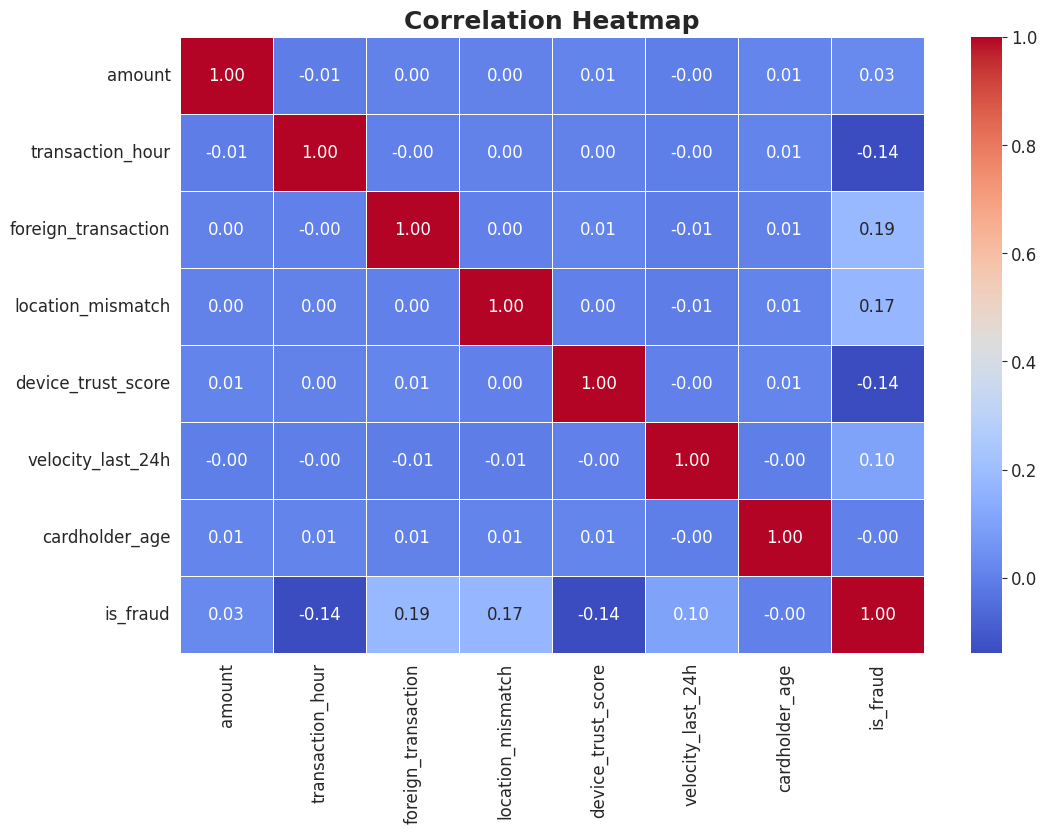

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap",fontsize=18)

plt.show()

In [34]:
# Check Categorical Columns
df.select_dtypes(include="object").columns

Index(['merchant_category'], dtype='object')

In [35]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["merchant_category"] = encoder.fit_transform(df["merchant_category"])

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,1,0,0,66,3,40,0
1,2,541.82,3,4,1,0,87,1,64,0
2,3,237.01,17,3,0,0,49,1,61,0
3,4,164.33,4,3,0,1,72,3,34,0
4,5,30.53,15,2,0,0,79,0,44,0


In [36]:
# Verify Data Types
df.dtypes

,0
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,int64
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64
is_fraud,int64


In [37]:
# Feature Selection
X = df.drop(["transaction_id", "is_fraud"], axis=1)

y = df["is_fraud"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (10000, 8)
Target Shape : (10000,)


In [38]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)


Training Data : (8000, 8)


In [39]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [40]:
# Logistic Regression Evaluation
print("Accuracy :", accuracy_score(y_test, lr_pred))

print("Precision :", precision_score(y_test, lr_pred))

print("Recall :", recall_score(y_test, lr_pred))

print("F1 Score :", f1_score(y_test, lr_pred))

print("ROC AUC :", roc_auc_score(y_test, lr_pred))

Accuracy : 0.958
Precision : 0.2631578947368421
Recall : 1.0
F1 Score : 0.4166666666666667
ROC AUC : 0.9786802030456853


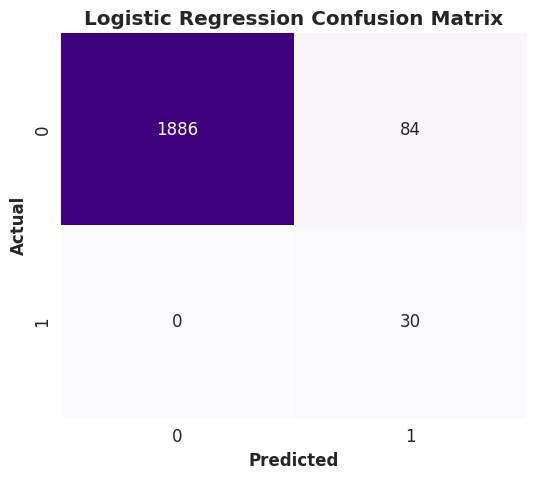

In [41]:
# Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [42]:
# Classification Report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      1.00      0.42        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000



In [44]:
# Decision Tree
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=8
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [45]:
# Decision Tree Evaluation
print("Accuracy :", accuracy_score(y_test, dt_pred))

print("Precision :", precision_score(y_test, dt_pred))

print("Recall :", recall_score(y_test, dt_pred))

print("F1 Score :", f1_score(y_test, dt_pred))

print("ROC AUC :", roc_auc_score(y_test, dt_pred))

Accuracy : 0.9995
Precision : 1.0
Recall : 0.9666666666666667
F1 Score : 0.9830508474576272
ROC AUC : 0.9833333333333334


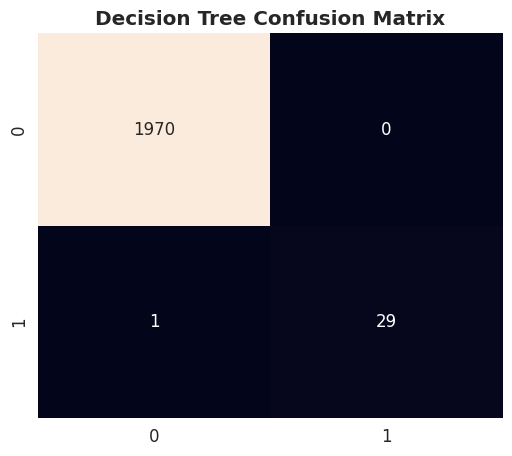

In [46]:
# Decision Tree Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, dt_pred),
    annot=True,
    fmt="d",
    cmap="rocket",
    cbar=False
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [47]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [48]:
# Random Forest Evaluation
print("Accuracy :", accuracy_score(y_test, rf_pred))

print("Precision :", precision_score(y_test, rf_pred))

print("Recall :", recall_score(y_test, rf_pred))

print("F1 Score :", f1_score(y_test, rf_pred))

print("ROC AUC :", roc_auc_score(y_test, rf_pred))

Accuracy : 0.9935
Precision : 1.0
Recall : 0.5666666666666667
F1 Score : 0.723404255319149
ROC AUC : 0.7833333333333333


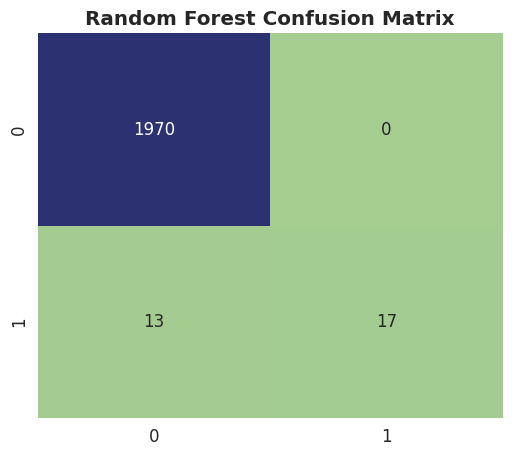

In [49]:
# Random Forest Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="crest",
    cbar=False
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [50]:
# Model Comparison
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9580,0.263158,1.000000,0.416667
1,Decision Tree,0.9995,1.000000,0.966667,0.983051
2,Random Forest,0.9935,1.000000,0.566667,0.723404


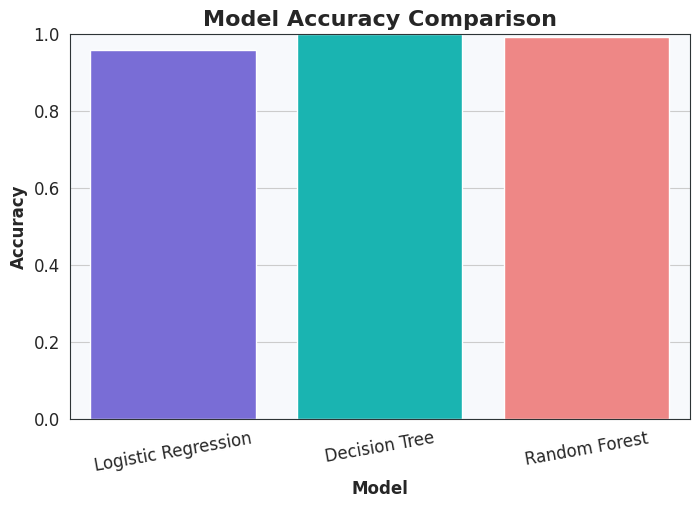

In [51]:
# Accuracy Comparison Graph
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison,
    palette=["#6C5CE7","#00CEC9","#FF7675"]
)

plt.title("Model Accuracy Comparison", fontsize=16)

plt.ylim(0,1)

plt.xticks(rotation=10)

plt.show()

In [52]:
# Feature Importance (Random Forest)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,device_trust_score,0.266114
1,transaction_hour,0.263271
6,velocity_last_24h,0.126128
3,foreign_transaction,0.124603
4,location_mismatch,0.118071
0,amount,0.050295
7,cardholder_age,0.031754
2,merchant_category,0.019765


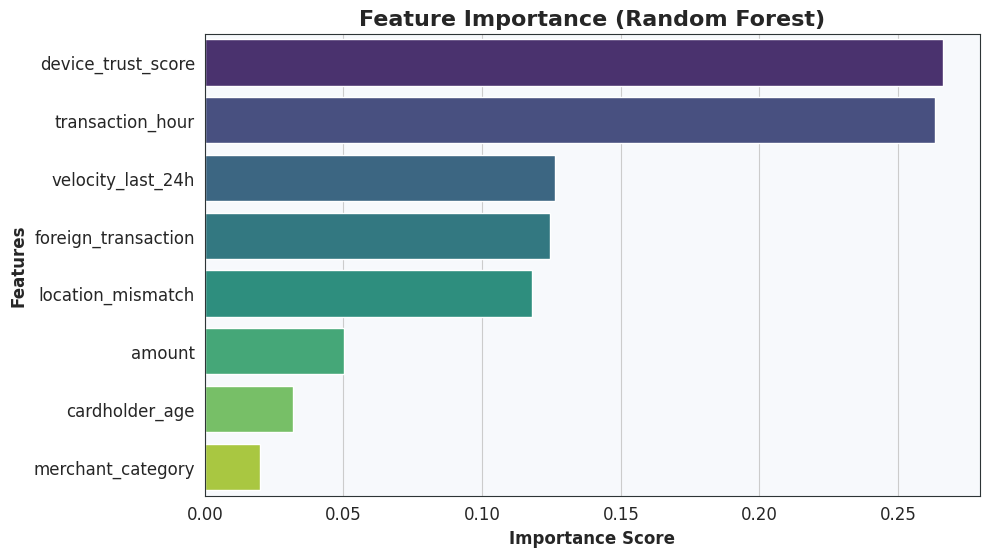

In [53]:
# Feature Importance Graph
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette="viridis"
)

plt.title("Feature Importance (Random Forest)", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

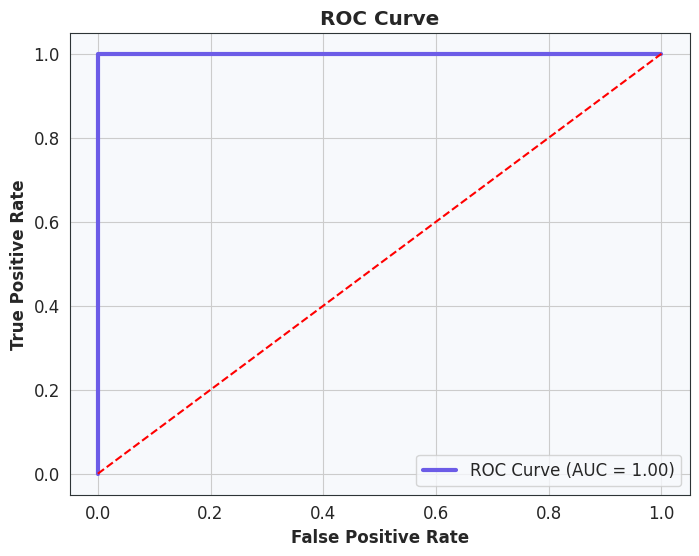

In [54]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

rf_probability = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    rf_probability
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    color="#6C5CE7",
    linewidth=3,
    label="ROC Curve (AUC = %0.2f)" % roc_auc
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [61]:
# Save Best Model
import joblib

joblib.dump(rf, "credit_card_fraud_model.pkl")

print(" Model Saved Successfully")

 Model Saved Successfully


In [56]:
# Load Saved Model
loaded_model = joblib.load(
    "credit_card_fraud_model.pkl"
)

In [57]:
# Predict New Transaction
sample = pd.DataFrame({

    "amount":[3500],

    "transaction_hour":[14],

    "merchant_category":[2],

    "foreign_transaction":[1],

    "location_mismatch":[0],

    "device_trust_score":[82],

    "velocity_last_24h":[4],

    "cardholder_age":[35]

})

prediction = loaded_model.predict(sample)

print(prediction)

[0]


In [59]:
# Prediction Result
if prediction[0]==1:

    print(" Fraudulent Transaction Detected")

else:

    print(" Genuine Transaction")

 Genuine Transaction


In [60]:
# Model Performance Summary
print("="*50)

print("Credit Card Fraud Detection Project")

print("="*50)

print("Best Model : Random Forest")

print("Accuracy :",accuracy_score(y_test,rf_pred))

print("Precision :",precision_score(y_test,rf_pred))

print("Recall :",recall_score(y_test,rf_pred))

print("F1 Score :",f1_score(y_test,rf_pred))

print("ROC AUC :",roc_auc_score(y_test,rf_pred))

Credit Card Fraud Detection Project
Best Model : Random Forest
Accuracy : 0.9935
Precision : 1.0
Recall : 0.5666666666666667
F1 Score : 0.723404255319149
ROC AUC : 0.7833333333333333


# Conclusion

This project successfully developed a Credit Card Fraud Detection system using Machine Learning to classify transactions as genuine or fraudulent. The dataset was preprocessed, explored through data analysis, and used to train multiple classification models, including Logistic Regression, Decision Tree, and Random Forest. After evaluating their performance, the Random Forest model achieved the best results. This project demonstrates the complete machine learning workflow and shows how ML can help improve the accuracy and efficiency of fraud detection in financial transactions.